In [2]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Loading the dataframe
input_path = Path("..") / 'data' / 'processed' / 'dataset_processed.csv'
df = pd.read_csv(input_path)
display(df.head(5))

,latitude,longitude,temperature_2m_max,sunrise,sunset,daylight_duration,precipitation_sum,shortwave_radiation_sum,et0_fao_evapotranspiration,cloud_cover_mean,...,SPLI,SPI,SETI,SSTI,SSRI,SWSI,SCCI,SPMI,SPEI,SSMI
0,42.685696,2.685378,9.8,2017-01-01T07:19,2017-01-01T16:26,32800.70,0.0,7.88,0.95,47,...,0.124164,0.66519,0.380523,-1.018795,-0.124164,0.66519,-1.018795,0.66519,0.66519,0.124164
1,42.685696,2.685378,9.0,2017-01-02T07:19,2017-01-02T16:27,32850.58,0.0,4.29,0.56,93,...,0.124164,0.66519,0.380523,-1.018795,-0.124164,0.66519,-1.018795,0.66519,0.66519,0.124164
2,42.685696,2.685378,11.7,2017-01-03T07:19,2017-01-03T16:28,32904.28,0.0,8.02,1.59,3,...,0.124164,0.66519,0.380523,-1.018795,-0.124164,0.66519,-1.018795,0.66519,0.66519,0.124164
3,42.685696,2.685378,10.6,2017-01-04T07:19,2017-01-04T16:29,32961.75,0.0,8.08,2.52,5,...,0.124164,0.66519,0.380523,-1.018795,-0.124164,0.66519,-1.018795,0.66519,0.66519,0.124164
4,42.685696,2.685378,7.1,2017-01-05T07:19,2017-01-05T16:30,33022.91,0.0,6.93,2.07,14,...,0.124164,0.66519,0.380523,-1.018795,-0.124164,0.66519,-1.018795,0.66519,0.66519,0.124164


In [3]:
#def preprocessing(df):
"""
This function performed the following steps:
preprocessing preparation (dropping undesire columns; splitting the target 'y' and the explicatives features 'X')
Temporal split (X_train; X_test; y_train & y_test)
At the end, this function return the different datasets to perform Machine Learning algorithms."""# Setting 'date_index' as index in the dataframe
df = df.set_index("date_index", drop=False)
df.index = pd.to_datetime(df.index)

 # Build the monthly panel
std_cols = df.filter(regex=r"^S.*I$").columns
df = df.filter(std_cols)
df_monthly = df.groupby(df.index.to_period('M')).mean()

display(df_monthly.head())

,SPLI,SPI,SETI,SSTI,SSRI,SWSI,SCCI,SPMI,SPEI,SSMI
date_index,,,,,,,,,,
2017-01,0.124164,0.665190,0.380523,-1.018795,-0.124164,0.665190,-1.018795,0.665190,0.665190,0.124164
2017-02,0.124164,0.665190,-0.124164,-0.380523,-0.124164,0.124164,-0.124164,-0.380523,0.665190,1.018795
2017-03,0.665190,0.665190,1.018795,0.665190,1.018795,-1.018795,-1.018795,0.124164,0.380523,1.595180
2017-04,0.665190,-1.595180,1.595180,0.124164,1.595180,1.018795,-1.595180,1.595180,-1.595180,1.018795
2017-05,0.665190,-0.380523,-0.124164,-0.124164,0.380523,-1.595180,-0.380523,0.124164,-0.380523,0.665190


## Prophet
Prophet (Meta's additive decomposition model): fits target ≈ trend + seasonality + regressors + noise. It's curve-fitting on time, not autoregressive: it does not use lagged values of the target.

- Fastest to a working baseline (minutes), robust to gaps and irregular sampling, minimal tuning — real value in a 10-day sprint.
- Handles multiple/complex seasonality and trend changepoints automatically.
- add_regressor makes adding weather trivial.
- Weakness that matters here: ignoring autocorrelation tends to hurt exactly on slow, persistent physical series like groundwater.

### 1. Baseline Prophet - univariate

In [4]:
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric


23:43:19 - cmdstanpy - INFO - Chain [1] start processing


Train: 2017-01-01 00:00:00 to 2025-07-01 00:00:00
Test:  2025-08-01 00:00:00 to 2026-07-01 00:00:00


23:43:19 - cmdstanpy - INFO - Chain [1] done processing


            ds      yhat  yhat_lower  yhat_upper     trend    yearly
108 2026-01-01 -0.559956   -2.117392    0.992356 -0.536626 -0.023330
109 2026-02-01 -0.559491   -2.256909    1.018095 -0.546272 -0.013219
110 2026-03-01 -0.554578   -2.311006    1.076437 -0.554984  0.000406
111 2026-04-01 -0.550685   -2.237614    1.077474 -0.564630  0.013945
112 2026-05-01 -0.553087   -2.049213    1.063032 -0.573965  0.020878
113 2026-06-01 -0.562216   -2.198494    0.986973 -0.583611  0.021395
114 2026-07-01 -0.569235   -2.210835    1.016459 -0.592946  0.023711
115 2026-08-01 -0.625359   -2.288610    0.999696 -0.602592 -0.022767
116 2026-09-01 -0.626558   -2.254771    1.030527 -0.612238 -0.014320
117 2026-10-01 -0.625853   -2.257289    0.977404 -0.621573 -0.004280


  0%|          | 0/28 [00:00<?, ?it/s]

23:43:19 - cmdstanpy - INFO - Chain [1] start processing
23:43:20 - cmdstanpy - INFO - Chain [1] done processing
23:43:20 - cmdstanpy - INFO - Chain [1] start processing
23:43:20 - cmdstanpy - INFO - Chain [1] done processing
23:43:21 - cmdstanpy - INFO - Chain [1] start processing
23:43:21 - cmdstanpy - INFO - Chain [1] done processing
23:43:21 - cmdstanpy - INFO - Chain [1] start processing
23:43:22 - cmdstanpy - INFO - Chain [1] done processing
23:43:22 - cmdstanpy - INFO - Chain [1] start processing
23:43:22 - cmdstanpy - INFO - Chain [1] done processing
23:43:23 - cmdstanpy - INFO - Chain [1] start processing
23:43:23 - cmdstanpy - INFO - Chain [1] done processing
23:43:23 - cmdstanpy - INFO - Chain [1] start processing
23:43:24 - cmdstanpy - INFO - Chain [1] done processing
23:43:24 - cmdstanpy - INFO - Chain [1] start processing
23:43:24 - cmdstanpy - INFO - Chain [1] done processing
23:43:25 - cmdstanpy - INFO - Chain [1] start processing
23:43:25 - cmdstanpy - INFO - Chain [1]

   horizon      rmse       mae
0  22 days  0.599731  0.405558
1  23 days  0.390025  0.304425
2  24 days  0.759934  0.589524
3  25 days  0.959449  0.845897
4  26 days  0.977372  0.885054
5  27 days  0.923009  0.823544
6  28 days  1.186730  0.958646
7  29 days  1.862913  1.568892
8  30 days  2.095639  1.859716
9  48 days  2.114030  1.924485
10 49 days  1.955684  1.643014
11 50 days  1.641701  1.178000
12 51 days  1.393630  0.936758
13 52 days  0.470575  0.343067
14 53 days  0.388056  0.299526
15 54 days  0.787354  0.600919
16 55 days  0.995422  0.872484
17 56 days  1.011444  0.910032
18 57 days  0.950937  0.838081
19 58 days  1.236411  0.989043
20 59 days  1.880656  1.586299
21 60 days  2.209571  2.053817
22 79 days  2.044796  1.767904
23 80 days  1.740582  1.296770
24 81 days  1.513081  1.057811
25 82 days  0.911344  0.525169
26 83 days  0.389494  0.299268
27 84 days  0.795373  0.603514
28 85 days  1.010308  0.883403
29 86 days  1.030616  0.928012
30 87 days  0.965343  0.852170
31 88 da

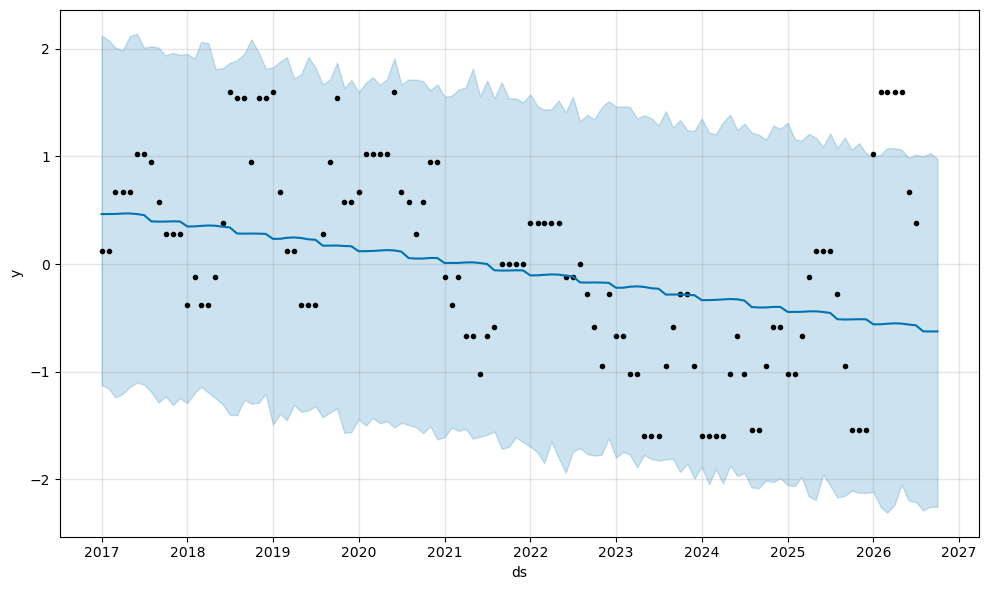

In [ ]:

# build the two-column frame for Prophet
data = {
    "ds": df_monthly.index.to_timestamp(),
    "y": df_monthly["SPLI"].values
}
df_prophet = pd.DataFrame(data)

# Keep the last 12 months for test
df_train = df_prophet.iloc[:-12]
df_test = df_prophet.iloc[-12:]
# Check split
print(f"Train: {df_train.ds.min()} to {df_train.ds.max()}")
print(f"Test:  {df_test.ds.min()} to {df_test.ds.max()}")

# Instantiate and train model with seasonality flags
m = Prophet(weekly_seasonality=False, daily_seasonality=False, yearly_seasonality=True, interval_width= 0.95, changepoint_prior_scale=0.1)
#m.add_seasonality(        # adding monthly seasonality to monthly data is noise -> overfitting
#    name="monthly",   
#    period=30.5,          # Période en jours
#    fourier_order=6       # Nb de termes Fourier (plus = plus flexible)
#)
m.fit(df_prophet)

# Forecast the horizon
future = m.make_future_dataframe(periods=3, freq="MS")
forecast = m.predict(future)

# Colonnes clés dans forecast :
#   ds          → date
#   yhat        → prévision (valeur centrale)
#   yhat_lower  → borne basse de l'intervalle de confiance
#   yhat_upper  → borne haute de l'intervalle de confiance
#   trend       → composante tendance seule
#   yearly      → composante saisonnalité annuelle

print(forecast[["ds", "yhat", "yhat_lower", "yhat_upper", "trend", "yearly"]].tail(10))

# Evaluate: rolling backtest with cross-validation 
# re-fits the model internally on each fold, using only the data before each cutoff. 
# it ignores the parameters from initial m.fit() and clones the model spec (seasonalities, priors), 
# then refits on each expanding past-window and predicts the future horizon
df_cv = cross_validation(
    m,
    horizon="90 days",
    period="30 days",
    initial="2555 days"
    )

df_perf = performance_metrics(df_cv)
print(df_perf[["horizon", "rmse", "mae"]])

# Visualize
fig1 = m.plot(forecast)   
#fig2 = plot_cross_validation_metric(df_cv, metric="rmse")
plt.show()


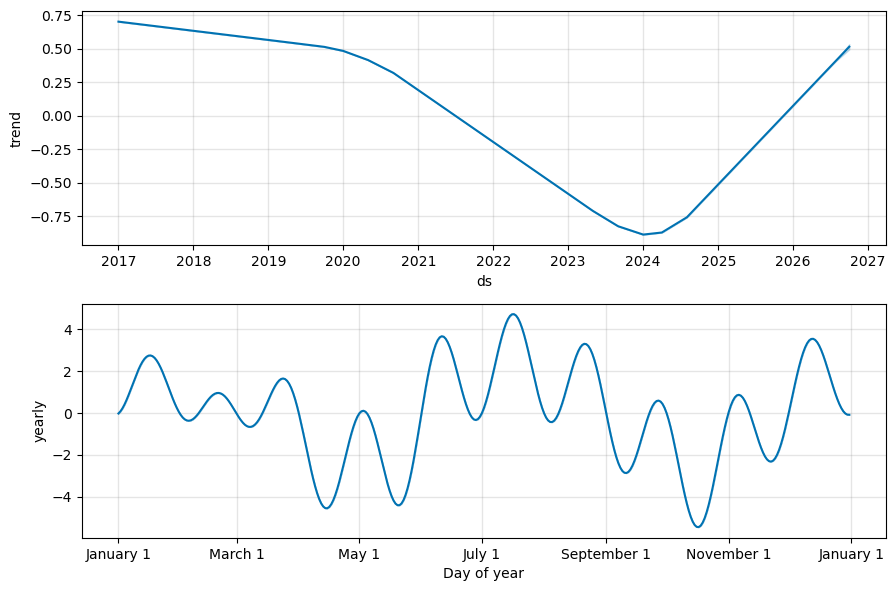

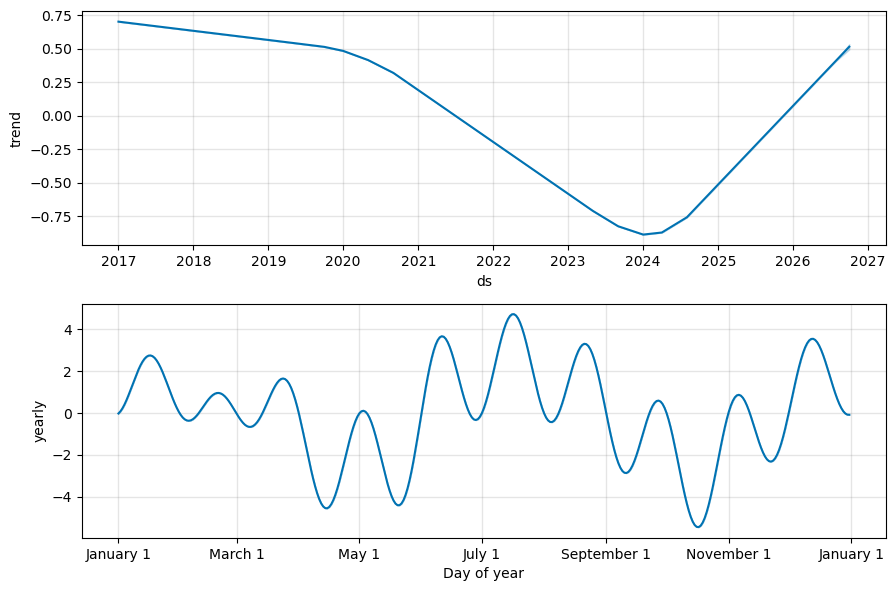

In [ ]:
m.plot_components(forecast)

Observation: Prophet captures only trend/seasonality and explains ~no variance; because no autocorrelation no lagged weather recovers it.

### 2. Prophet with regressors
- Note: Prophet requires the regressor values for the future months

23:59:19 - cmdstanpy - INFO - Chain [1] start processing


OK — lag cols: ['SSMI_lag2', 'SPEI_lag2', 'SPI_lag2'] ... | df_prophet: (113, 6)


23:59:19 - cmdstanpy - INFO - Chain [1] done processing


            ds      yhat  yhat_lower  yhat_upper     trend    yearly
105 2025-12-01 -0.433189   -1.745609    0.768377 -0.229708  0.013927
106 2026-01-01 -0.565855   -1.883155    0.724599 -0.234496  0.000996
107 2026-02-01  0.177285   -1.079200    1.338328 -0.239284  0.004843
108 2026-03-01  0.546404   -0.680163    1.812164 -0.243609 -0.010365
109 2026-04-01  1.020392   -0.285874    2.362053 -0.248397 -0.003275
110 2026-05-01  0.637401   -0.714875    1.839886 -0.253030  0.005553
111 2026-06-01 -0.289145   -1.490731    0.923650 -0.257818  0.011450
112 2026-07-01 -0.179029   -1.442236    1.138181 -0.262452  0.015680
113 2026-08-01 -0.593069   -1.852672    0.691139 -0.267240 -0.044976
114 2026-09-01 -0.534361   -1.831712    0.783755 -0.272028 -0.021137


  0%|          | 0/27 [00:00<?, ?it/s]

23:59:20 - cmdstanpy - INFO - Chain [1] start processing
23:59:20 - cmdstanpy - INFO - Chain [1] done processing
23:59:20 - cmdstanpy - INFO - Chain [1] start processing
23:59:21 - cmdstanpy - INFO - Chain [1] done processing
23:59:21 - cmdstanpy - INFO - Chain [1] start processing
23:59:22 - cmdstanpy - INFO - Chain [1] done processing
23:59:22 - cmdstanpy - INFO - Chain [1] start processing
23:59:23 - cmdstanpy - INFO - Chain [1] done processing
23:59:23 - cmdstanpy - INFO - Chain [1] start processing
23:59:23 - cmdstanpy - INFO - Chain [1] done processing
23:59:23 - cmdstanpy - INFO - Chain [1] start processing
23:59:24 - cmdstanpy - INFO - Chain [1] done processing
23:59:24 - cmdstanpy - INFO - Chain [1] start processing
23:59:25 - cmdstanpy - INFO - Chain [1] done processing
23:59:25 - cmdstanpy - INFO - Chain [1] start processing
23:59:25 - cmdstanpy - INFO - Chain [1] done processing
23:59:26 - cmdstanpy - INFO - Chain [1] start processing
23:59:26 - cmdstanpy - INFO - Chain [1]

   horizon      rmse       mae
0  21 days  0.519323  0.424149
1  22 days  0.535528  0.454894
2  23 days  0.781998  0.720809
3  24 days  0.968058  0.886893
4  25 days  1.016397  0.870431
5  26 days  0.993978  0.867654
6  27 days  0.838122  0.732620
7  28 days  0.912607  0.833512
8  29 days  1.408143  1.288249
9  30 days  1.597043  1.488015
10 49 days  1.432253  1.228379
11 50 days  1.032242  0.728564
12 51 days  0.809419  0.570103
13 52 days  0.530395  0.452225
14 53 days  0.781606  0.720187
15 54 days  0.992675  0.907391
16 55 days  1.063039  0.908965
17 56 days  1.047475  0.914147
18 57 days  0.908150  0.795872
19 58 days  1.015669  0.899389
20 59 days  1.407776  1.306823
21 60 days  1.574466  1.434696


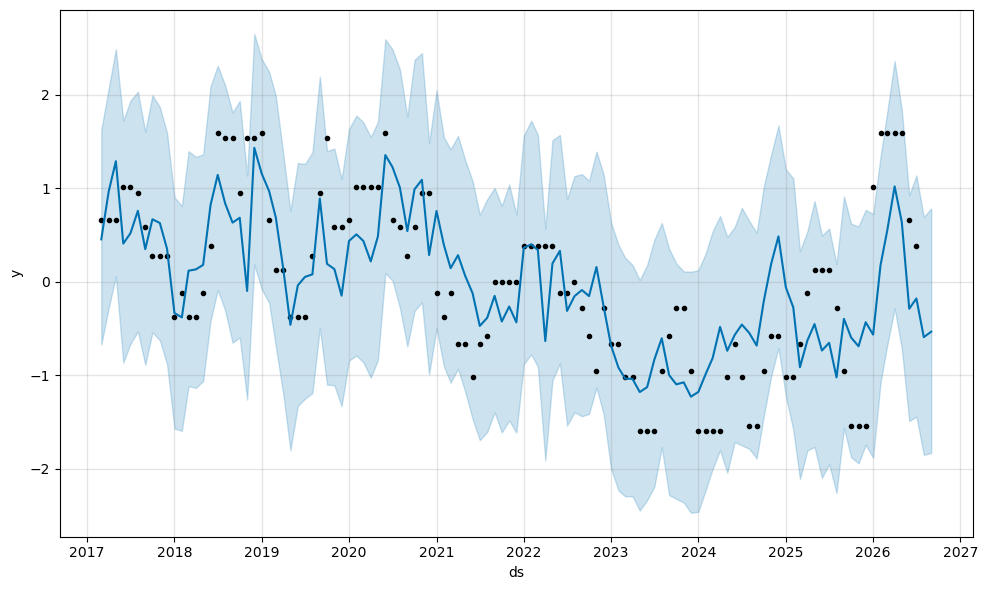

In [ ]:
regressors = ["SSMI", "SPEI", "SPI", "SSTI"]#["SPI","SETI","SSTI","SSRI","SWSI","SCCI","SPMI","SPEI","SSMI"]
h = 3   # horizon == lag (months). This equality is what makes the forecast feasible.
assert not (set(regressors) - set(df_monthly.columns)), \
    f"missing regressors: {set(regressors) - set(df_monthly.columns)}"

#  Build future-aware lagged regressors  
# Extend the monthly index by h BEFORE shifting, so shift(h) pulls observed
# values into the future rows instead of leaving them NaN.
future_idx = pd.period_range(df_monthly.index.min(),
                             periods=len(df_monthly) + h,
                             freq=df_monthly.index.freqstr)   # e.g. "M"
df_ext = df_monthly.reindex(future_idx)                       # h new rows, NaN for now

for col in regressors:
    df_ext[f"{col}_lag{h}"] = df_ext[col].shift(h)
regressor_cols = [f"{col}_lag{h}" for col in regressors]
assert all(c in df_ext.columns for c in regressor_cols), "lag columns not created!"


#  Single frame: ds, y, regressors 
df_all = pd.DataFrame({
    "ds": df_ext.index.to_timestamp(),
    "y":  df_ext["SPLI"].values,          # NaN on the h future rows — expected
})
for col in regressor_cols:
    df_all[col] = df_ext[col].values

# Training frame: y known AND regressors known
df_prophet = df_all.dropna(subset=["y"] + regressor_cols).reset_index(drop=True)

# Future frame for predict: regressors known (y not needed).
# Spans history + the h forecast months, so m.plot() works too.
future = df_all[["ds"] + regressor_cols].dropna(subset=regressor_cols).reset_index(drop=True)
print("OK — lag cols:", regressor_cols[:3], "... | df_prophet:", df_prophet.shape)

m = Prophet(weekly_seasonality=False, daily_seasonality=False,
            yearly_seasonality=True, interval_width=0.95,
            changepoint_prior_scale=0.05)   # 8x default — tune via CV, don't hard-code
for col in regressor_cols:
    m.add_regressor(col)
m.fit(df_prophet)          # <- swap to df_train for the manual testing route

#  Forecast 
forecast = m.predict(future)   # replaces make_future_dataframe + merge

print(forecast[["ds", "yhat", "yhat_lower", "yhat_upper", "trend", "yearly"]].tail(10))

#  Cross-validation
# Units are calendar days, not months, so "90 days" ~ 3 months but folds don't
# land on clean month boundaries.
df_cv = cross_validation(m, horizon="90 days", period="30 days", initial="2555 days")
df_perf = performance_metrics(df_cv)
print(df_perf[["horizon", "rmse", "mae"]])

#  Visualize 
fig1 = m.plot(forecast)
plt.show()

In [11]:
# ============================================================
# SANITY CHECKS — run after df_ext / df_prophet / future exist
# ============================================================

# 1. Index integrity — gaps or duplicates silently corrupt lags
print("freq:", df_monthly.index.freqstr)
print("monotonic:", df_monthly.index.is_monotonic_increasing)
print("duplicates:", df_monthly.index.duplicated().sum())
# a clean monthly PeriodIndex has diffs all == 1 month:
gaps = df_monthly.index.to_timestamp().to_series().diff().dt.days.dropna()
print("month-gap days (should be ~28–31):", gaps.min(), gaps.max())

# 2. Lag correctness — the check that actually proves fix #3 worked
col = "SPI"
first_future = future["ds"].iloc[-h]          # first forecast month
lag_val = future.loc[future.ds == first_future, f"{col}_lag{h}"].values[0]
raw_val = df_monthly[col].iloc[-h]            # observed value h months before
print(f"{col}_lag{h} at {first_future.date()} = {lag_val:.4f} | raw {h}m ago = {raw_val:.4f} | match:", 
      abs(lag_val - raw_val) < 1e-9)

# 3. Future rows well-formed — regressors present, y absent
print("future tail NaN in regressors (must be 0):",
      future[regressor_cols].tail(h).isna().sum().sum())
print("y present on future months? (should be all NaN):",
      df_all["y"].tail(h).notna().sum())

# 4. How much data the dropna() cost you
print("rows: raw", len(df_ext), "| usable", len(df_prophet),
      "| dropped", len(df_ext) - len(df_prophet))

# 5. Sample size vs model complexity — rule of thumb ≥10 obs per regressor
print("obs per regressor:", round(len(df_prophet) / len(regressor_cols), 1),
      "(< 10 = overfitting risk)")

# 6. Dead regressors — zero variance adds noise, no signal
zero_var = [c for c in regressor_cols if df_prophet[c].std() == 0]
print("constant regressors (drop these):", zero_var)

# 7. Multicollinearity — 9 lagged indices are often near-duplicates
corr = df_prophet[regressor_cols].corr().abs()
high = (corr.where(~np.eye(len(corr), dtype=bool)) > 0.9).stack()
print("regressor pairs |corr|>0.9:\n", high[high].index.tolist())

# 8. Signal check — does each regressor actually relate to the target?
print("corr(regressor, y):")
print(df_prophet[regressor_cols].corrwith(df_prophet["y"]).sort_values())

# 9. Scale awareness — Prophet standardizes internally, but wild ranges hint at outliers
print(df_prophet[regressor_cols].describe().loc[["min", "max", "mean", "std"]].T)

# 10. Split hygiene — no date overlap, no leakage across the boundary
print("train ends:", df_train.ds.max(), "| test starts:", df_test.ds.min())
print("overlap:", set(df_train.ds) & set(df_test.ds))   # must be empty

freq: M
monotonic: True
duplicates: 0
month-gap days (should be ~28–31): 28.0 31.0
SPI_lag3 at 2026-08-01 = -0.6652 | raw 3m ago = -0.6652 | match: True
future tail NaN in regressors (must be 0): 0
y present on future months? (should be all NaN): 0
rows: raw 118 | usable 112 | dropped 6
obs per regressor: 12.4 (< 10 = overfitting risk)
constant regressors (drop these): []
regressor pairs |corr|>0.9:
 []
corr(regressor, y):
SSTI_lag3   -0.298583
SCCI_lag3   -0.144268
SETI_lag3   -0.130248
SWSI_lag3   -0.090381
SSRI_lag3   -0.072021
SPMI_lag3   -0.026031
SPI_lag3     0.337477
SPEI_lag3    0.340989
SSMI_lag3    0.645168
dtype: float64
               min      max      mean       std
SPI_lag3  -1.59518  1.59518  0.018433  0.919825
SETI_lag3 -1.59518  1.59518 -0.009072  0.897454
SSTI_lag3 -1.59518  1.59518 -0.000793  0.908185
SSRI_lag3 -1.59518  1.59518 -0.014243  0.889992
SWSI_lag3 -1.59518  1.59518  0.008544  0.909468
SCCI_lag3 -1.59518  1.59518  0.037582  0.896905
SPMI_lag3 -1.59518  1.59